In [ ]:
# -*- coding: utf-8 -*-
"""Preprocessing_Water_Quality.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Lp_n__4i1Zb5QIvN6PjdKyKkW7yLAs_t
"""

import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD DATA
# ─────────────────────────────────────────────

def load_data(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    print(f"[INFO] Loaded dataset: {df.shape[0]} rows × {df.shape[1]} columns")
    return df

# 2. INITIAL DIAGNOSTICS
# ─────────────────────────────────────────────

def run_diagnostics(df: pd.DataFrame) -> None:
    print("\n[DIAGNOSTICS] Missing values per column:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    for col in df.columns:
        if missing[col] > 0:
            print(f"  {col}: {missing[col]} ({missing_pct[col]}%)")

    print("\n[DIAGNOSTICS] Target class distribution:")
    vc = df['Potability'].value_counts()
    print(f"  Not Potable (0): {vc[0]}  |  Potable (1): {vc[1]}")
    print(f"  Imbalance ratio: {vc[0] / vc[1]:.2f}:1")

    print("\n[DIAGNOSTICS] Outlier counts (IQR method) per feature:")
    for col in df.columns[:-1]:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        n_out = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)].shape[0]
        print(f"  {col}: {n_out} outliers")

# 3. HANDLE MISSING VALUES (KNN Imputation)
# ─────────────────────────────────────────────

def impute_missing(df: pd.DataFrame, n_neighbors: int = 5) -> pd.DataFrame:
    """
    Uses KNN Imputation so that each missing value is estimated from its
    k nearest neighbours in feature space — better than simple mean/median
    for correlated water-quality parameters.
    """
    feature_cols = df.columns[:-1].tolist()
    imputer = KNNImputer(n_neighbors=n_neighbors)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])

    remaining = df.isnull().sum().sum()
    print(f"\n[IMPUTATION] KNN imputation done (k={n_neighbors}). Remaining nulls: {remaining}")
    return df

# 4. REMOVE DUPLICATE ROWS
# ─────────────────────────────────────────────

def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    removed = before - len(df)
    print(f"\n[DEDUP] Removed {removed} duplicate rows. Rows remaining: {len(df)}")
    return df

# 5. OUTLIER CAPPING (Winsorization — IQR based)
# ─────────────────────────────────────────────

def cap_outliers(df: pd.DataFrame, factor: float = 1.5) -> pd.DataFrame:
    """
    Caps outliers at [Q1 - factor*IQR, Q3 + factor*IQR] rather than removing
    rows, which preserves dataset size — important with only 3 276 samples.
    RobustScaler downstream is also insensitive to remaining extreme values.
    """
    feature_cols = df.columns[:-1].tolist()
    capped_total = 0
    for col in feature_cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
        n_capped = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        df[col] = df[col].clip(lower=lower, upper=upper)
        capped_total += n_capped
    print(f"\n[OUTLIERS] Winsorized {capped_total} outlier values across all features.")
    return df

# 6. FEATURE ENGINEERING
# ─────────────────────────────────────────────

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds domain-relevant interaction / ratio features that may help
    Random Forest learn non-linear decision boundaries more easily.
    """
    # pH deviation from neutral (7) — standard water-quality metric
    df['ph_deviation'] = (df['ph'] - 7.0).abs()

    # Mineral load: Hardness + Solids ratio
    df['mineral_load'] = df['Hardness'] / (df['Solids'] + 1e-9)

    # Chloramines to Conductivity interaction
    df['chloramines_conductivity'] = df['Chloramines'] * df['Conductivity']

    # Trihalomethanes per unit Organic Carbon — disinfection by-product proxy
    df['thm_per_carbon'] = df['Trihalomethanes'] / (df['Organic_carbon'] + 1e-9)

    # Turbidity to Solids ratio
    df['turbidity_solids_ratio'] = df['Turbidity'] / (df['Solids'] + 1e-9)

    print(f"\n[FEATURES] Engineered 5 new features. Total columns now: {df.shape[1]}")
    return df

# 7. SPLIT FEATURES / TARGET
# ─────────────────────────────────────────────

def split_X_y(df: pd.DataFrame):
    X = df.drop(columns=['Potability'])
    y = df['Potability']
    return X, y

# 8. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────

def split_train_test(X, y, test_size: float = 0.2, random_state: int = 42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y          # preserve class ratio in both splits
    )
    print(f"\n[SPLIT] Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
    print(f"  Train class dist: {dict(y_train.value_counts())}")
    print(f"  Test  class dist: {dict(y_test.value_counts())}")
    return X_train, X_test, y_train, y_test

# 9. HANDLE CLASS IMBALANCE (SMOTE)
# ─────────────────────────────────────────────

def apply_smote(X_train, y_train, random_state: int = 42):
    """
    SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic
    samples for the minority class in the training set ONLY — never on test,
    to prevent data leakage.
    """
    smote = SMOTE(random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    print(f"\n[SMOTE] After resampling — class distribution: {dict(pd.Series(y_resampled).value_counts())}")
    print(f"  Training rows after SMOTE: {X_resampled.shape[0]}")
    return X_resampled, y_resampled

# 10. FEATURE SCALING (RobustScaler)
# ─────────────────────────────────────────────

def scale_features(X_train, X_test):
    """
    RobustScaler uses median and IQR — not sensitive to the residual
    outliers that survived Winsorization. Fit ONLY on training data;
    transform both splits to prevent data leakage.

    Note: Random Forest is tree-based and does not require scaling for
    its core algorithm, but scaling ensures that any distance-based
    preprocessing (KNN imputation was already done, but for consistency
    and future pipeline extensions) behaves well.
    """
    scaler = RobustScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns
    )
    print("\n[SCALING] RobustScaler applied (fit on train, transform on train+test).")
    return X_train_scaled, X_test_scaled, scaler

# 11. DATA TYPE VALIDATION & SANITY CHECK
# ─────────────────────────────────────────────

def validate_output(X_train, X_test, y_train, y_test) -> None:
    assert X_train.isnull().sum().sum() == 0, "Training features still contain NaNs!"
    assert X_test.isnull().sum().sum() == 0, "Test features still contain NaNs!"
    assert set(y_train.unique()).issubset({0, 1}), "Unexpected label values in y_train!"
    assert set(y_test.unique()).issubset({0, 1}), "Unexpected label values in y_test!"
    print("\n[VALIDATION] All sanity checks passed. Data is ready for Random Forest training.")
    print(f"  Final X_train shape: {X_train.shape}")
    print(f"  Final X_test  shape: {X_test.shape}")

# 12. SAVE PREPROCESSED DATA
# ─────────────────────────────────────────────

def save_preprocessed(X_train, X_test, y_train, y_test,
                       out_dir: str = ".") -> None:
    import os
    os.makedirs(out_dir, exist_ok=True)

    X_train_out = X_train.copy()
    X_train_out['Potability'] = y_train.values
    X_train_out.to_csv(f"{out_dir}/train_preprocessed.csv", index=False)

    X_test_out = X_test.copy()
    X_test_out['Potability'] = y_test.values
    X_test_out.to_csv(f"{out_dir}/test_preprocessed.csv", index=False)

    print(f"\n[SAVE] Saved → {out_dir}/train_preprocessed.csv")
    print(f"[SAVE] Saved → {out_dir}/test_preprocessed.csv")

# MAIN PIPELINE
# ─────────────────────────────────────────────

def preprocess_pipeline(filepath: str, output_dir: str = "preprocessed_data"):
    print("=" * 60)
    print("  WATER QUALITY DATASET — PREPROCESSING PIPELINE")
    print("=" * 60)

    df = load_data(filepath)
    run_diagnostics(df)

    df = remove_duplicates(df)
    df = impute_missing(df, n_neighbors=5)
    df = cap_outliers(df, factor=1.5)
    df = engineer_features(df)

    X, y = split_X_y(df)
    X_train, X_test, y_train, y_test = split_train_test(X, y)

    X_train, y_train = apply_smote(X_train, y_train)
    X_train, X_test, scaler = scale_features(
        pd.DataFrame(X_train, columns=X.columns),
        X_test
    )

    validate_output(X_train, X_test, y_train, pd.Series(y_test))
    save_preprocessed(X_train, X_test, pd.Series(y_train), pd.Series(y_test), out_dir=output_dir)

    print("\n[DONE] Preprocessing complete. Files saved to:", output_dir)
    return X_train, X_test, pd.Series(y_train), pd.Series(y_test), scaler

import zipfile
import os

# ENTRY POINT
# ─────────────────────────────────────────────

if __name__ == "__main__":
    # Define the path to the zip file and the extraction directory
    zip_filepath = "/content/Water_Quality_Dataset .zip"
    extract_dir = "/content"

    # Unzip the file if it hasn't been extracted already
    if not os.path.exists(os.path.join(extract_dir, "water_potability.csv")):
        with zipfile.ZipFile(zip_filepath, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print(f"[INFO] Extracted {zip_filepath} to {extract_dir}")

    # Now, run the preprocessing pipeline with the correct filepath
    X_train, X_test, y_train, y_test, scaler = preprocess_pipeline(
        filepath=os.path.join(extract_dir, "water_potability.csv"),
        output_dir="preprocessed_data"
    )


[INFO] Extracted /content/Water_Quality_Dataset .zip to /content
  WATER QUALITY DATASET — PREPROCESSING PIPELINE
[INFO] Loaded dataset: 3276 rows × 10 columns

[DIAGNOSTICS] Missing values per column:
  ph: 491 (14.99%)
  Sulfate: 781 (23.84%)
  Trihalomethanes: 162 (4.95%)

[DIAGNOSTICS] Target class distribution:
  Not Potable (0): 1998  |  Potable (1): 1278
  Imbalance ratio: 1.56:1

[DIAGNOSTICS] Outlier counts (IQR method) per feature:
  ph: 46 outliers
  Hardness: 83 outliers
  Solids: 47 outliers
  Chloramines: 61 outliers
  Sulfate: 41 outliers
  Conductivity: 11 outliers
  Organic_carbon: 25 outliers
  Trihalomethanes: 33 outliers
  Turbidity: 19 outliers

[DEDUP] Removed 0 duplicate rows. Rows remaining: 3276

[IMPUTATION] KNN imputation done (k=5). Remaining nulls: 0

[OUTLIERS] Winsorized 488 outlier values across all features.

[FEATURES] Engineered 5 new features. Total columns now: 15

[SPLIT] Train: 2620 rows | Test: 656 rows
  Train class dist: {0: np.int64(1598), 1: 


[EDA] Displaying feature distributions:


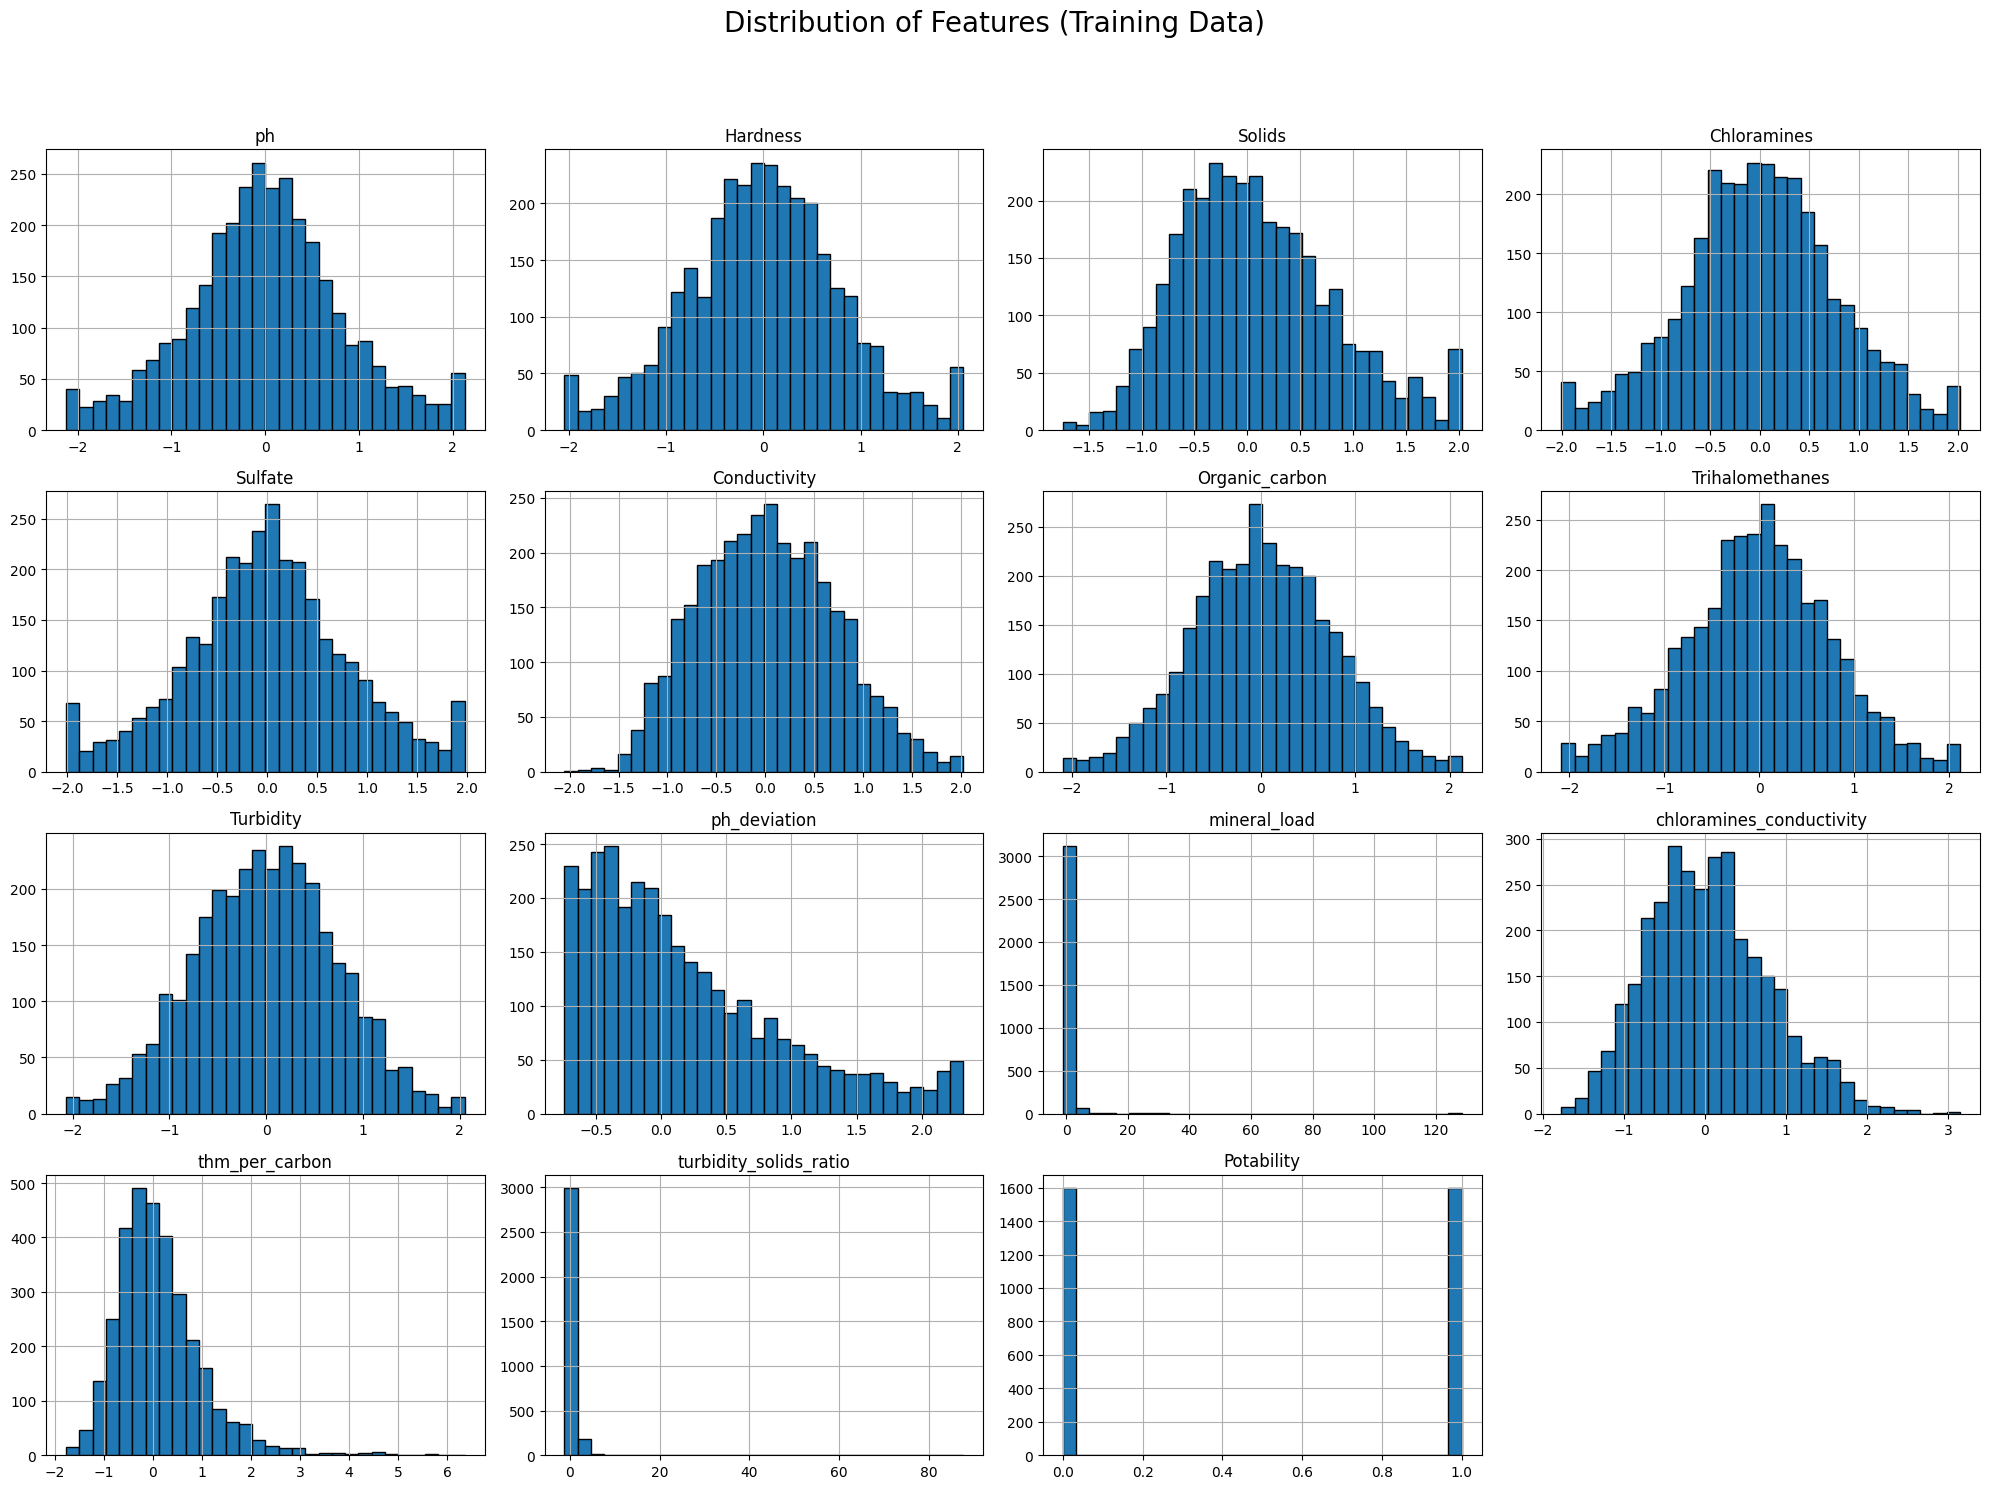

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine X_train and y_train for EDA
train_df = X_train.copy()
train_df['Potability'] = y_train

print("\n[EDA] Displaying feature distributions:")
# Plot histograms for all features
train_df.hist(bins=30, figsize=(20, 15), edgecolor='black')
plt.suptitle('Distribution of Features (Training Data)', y=1.02, fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Next, let's look at the correlation matrix of the features, including the target variable `Potability`.


[EDA] Displaying correlation matrix:


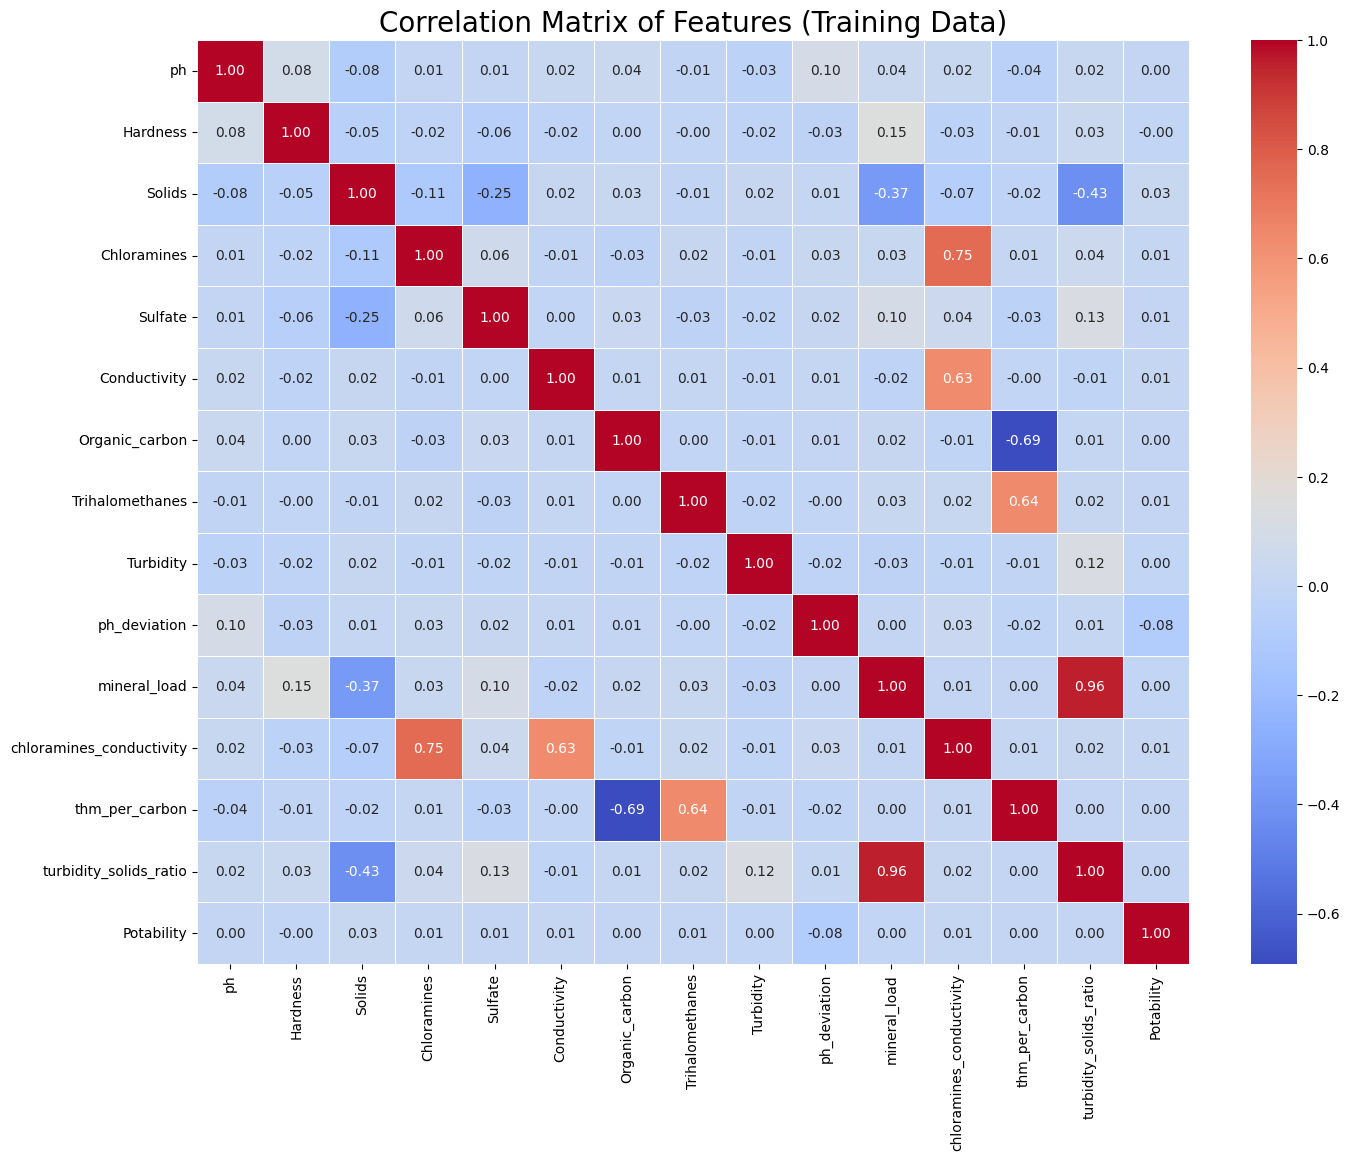

In [ ]:
print("\n[EDA] Displaying correlation matrix:")
# Calculate the correlation matrix
corr_matrix = train_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features (Training Data)', fontsize=20)
plt.show()

Finally, let's examine the relationship between each feature and the target variable `Potability` using box plots.


[EDA] Displaying feature vs. Potability relationship:


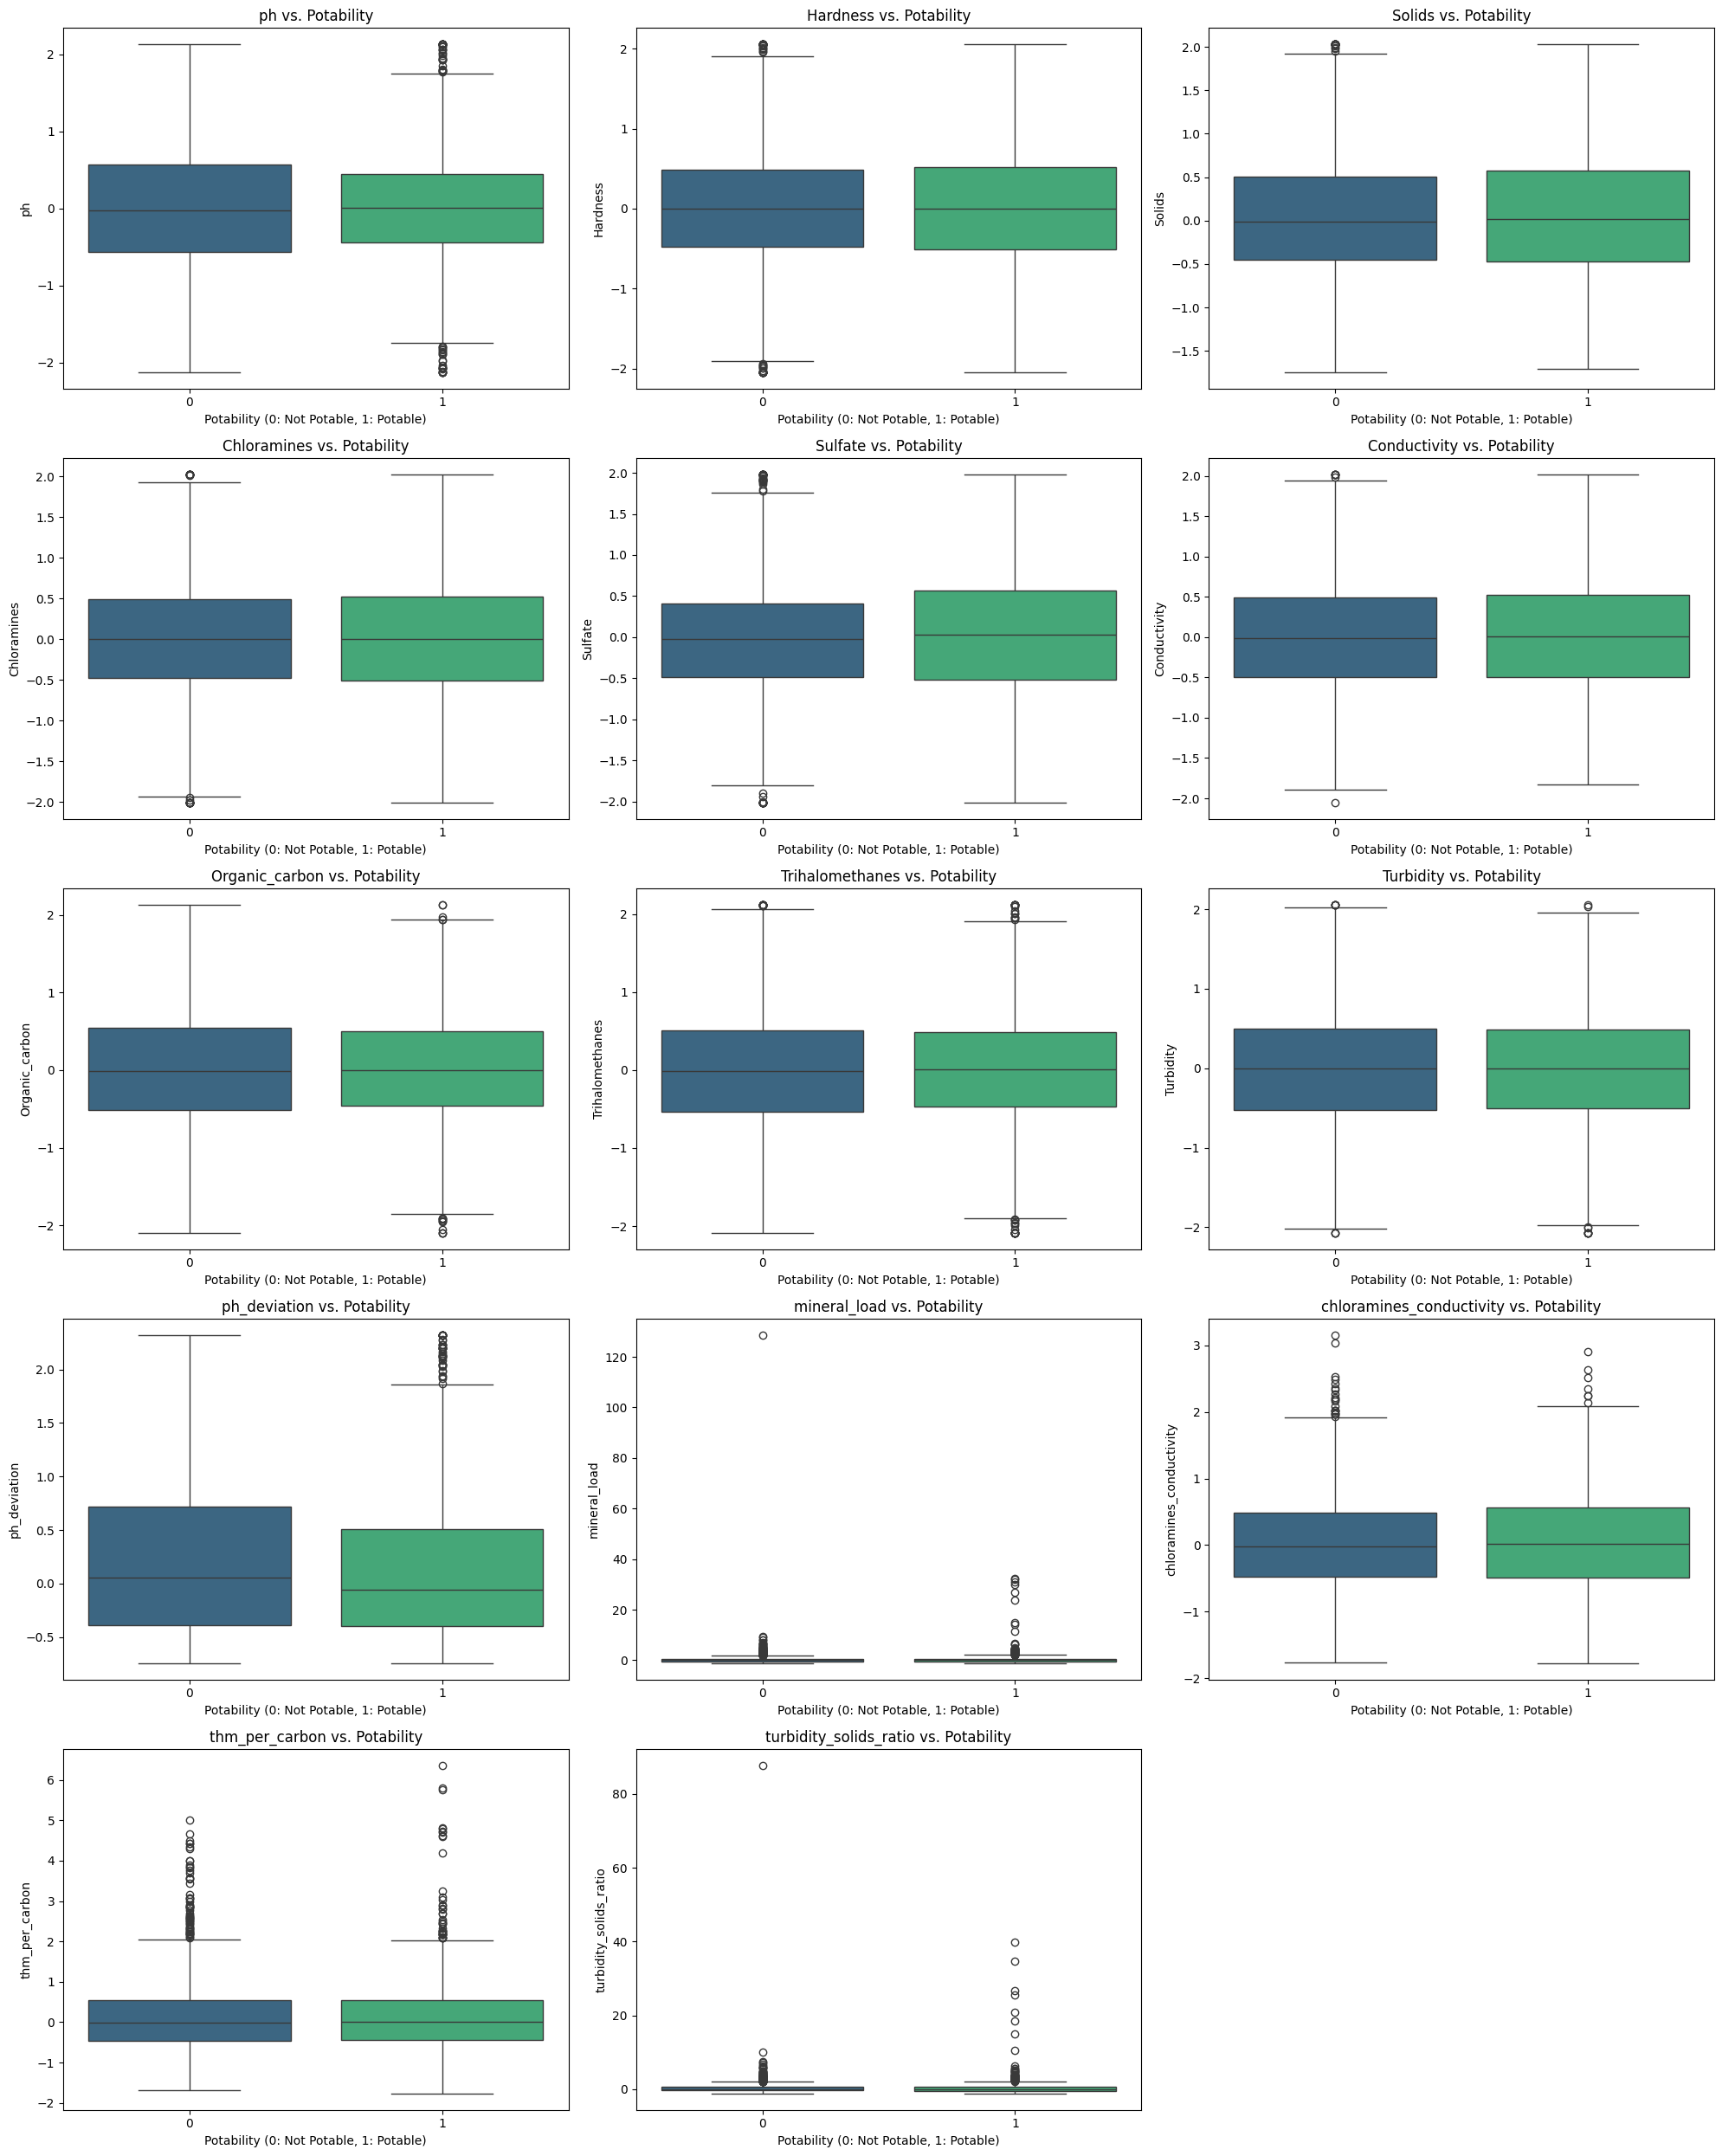

In [ ]:
print("\n[EDA] Displaying feature vs. Potability relationship:")
# Box plots for each feature against Potability
plt.figure(figsize=(20, 25))
for i, column in enumerate(train_df.columns[:-1]): # Exclude 'Potability'
    plt.subplot(5, 3, i + 1) # Adjust subplot grid as needed (e.g., 5 rows, 3 columns)
    sns.boxplot(x='Potability', y=column, data=train_df, palette='viridis')
    plt.title(f'{column} vs. Potability')
    plt.xlabel('Potability (0: Not Potable, 1: Potable)')
    plt.ylabel(column)
plt.tight_layout()
plt.show()